In [1]:
# Setup and Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append('utils')

from data_loader import DataLoader
from visualization import BehavioralVisualizer

print("✅ Imports successful!")


✅ Imports successful!


In [2]:
# File Path Configuration
NS6_FILE_PATH = r"D:\Data\ScienceCorp\neural.ns6"
CSV_FILE_PATH = r"D:\Data\ScienceCorp\actions.csv"

# Check if files exist
import os
ns6_exists = os.path.exists(NS6_FILE_PATH)
csv_exists = os.path.exists(CSV_FILE_PATH)

print(f"NS6 file exists: {ns6_exists}")
print(f"CSV file exists: {csv_exists}")

if ns6_exists and csv_exists:
    print("✅ All files found!")
else:
    print("❌ Please update file paths")


NS6 file exists: True
CSV file exists: True
✅ All files found!


In [3]:
# Load Behavioral Data
print("Loading behavioral data...")

loader = DataLoader(ns6_file_path=NS6_FILE_PATH, csv_file_path=CSV_FILE_PATH)
behavioral_data = loader.load_behavioral_data()

if behavioral_data is not None:
    print(f"\n✅ Behavioral data loaded successfully!")
    print(f"Shape: {behavioral_data.shape}")
    print(f"Trials available: {len(behavioral_data['trial'].unique())}")
    print(f"First 10 trials: {sorted(behavioral_data['trial'].unique())[:10]}")
else:
    print("❌ Failed to load behavioral data")


Loading behavioral data...
Found 141 trial start markers
Trial segmentation complete: 141 trials identified
Behavioral data loaded successfully!
Shape: (45971, 10)
Columns: ['timestamp', 'velocity_x', 'velocity_y', 'trial_start', 'trial_win', 'trial_lose', 'num_targets', 'target_index', 'trial', 'trial_outcome']
Trials segmented: 141 trials identified
Trial outcomes: {'win': 127, 'lose': 13, 'incomplete': 1}

✅ Behavioral data loaded successfully!
Shape: (45971, 10)
Trials available: 141
First 10 trials: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


In [4]:
# 🚀 Efficient Neural Data Loading (CORRECTED VERSION)
print("🚀 Loading neural data efficiently - FIXED PROXY HANDLING")
print("="*60)

# First, reload the DataLoader
import importlib
import sys
if 'utils.data_loader' in sys.modules:
    importlib.reload(sys.modules['utils.data_loader'])
    print("✅ DataLoader module reloaded with proxy fixes")

from utils.data_loader import DataLoader

# Create new loader instance
loader = DataLoader(ns6_file_path=NS6_FILE_PATH, csv_file_path=CSV_FILE_PATH)

# Reload behavioral data  
print("Re-loading behavioral data...")
behavioral_data = loader.load_behavioral_data()

if behavioral_data is not None:
    # Select first 5 trials for testing (smaller load for validation)
    first_5_trials = sorted(behavioral_data['trial'].unique())[:5]
    print(f"Testing with trials: {first_5_trials}")
    
    # Load neural data using the FIXED method with robust proxy handling
    neural_data = loader.load_neural_data_for_trials_simple(
        NS6_FILE_PATH,
        trial_numbers=first_5_trials,
        buffer_seconds=3.0,     # Smaller buffer for testing
        max_channels=24,        # Fewer channels for testing
        downsample_factor=4,    # More aggressive downsampling for testing
        force_reload=True
    )
    
    if neural_data is not None:
        print("\n🎉 SUCCESS! Neural data loaded with fixed proxy handling!")
        print("="*60)
        print(f"Data shape: {neural_data['raw_data'].shape}")
        print(f"Sampling rate: {neural_data['sampling_rate']} Hz")
        print(f"Duration: {neural_data['metadata']['duration']:.2f} seconds")
        print(f"Memory usage: {neural_data['raw_data'].nbytes / 1024**2:.1f} MB")
        print(f"Loaded trials: {neural_data['metadata']['loaded_trials']}")
        
        # Calculate efficiency
        full_file_size_mb = 16492.0  # Estimated full file size
        actual_memory_mb = neural_data['raw_data'].nbytes / 1024**2
        memory_savings = (1 - (actual_memory_mb / full_file_size_mb)) * 100
        
        print(f"\n💾 Efficiency:")
        print(f"- Memory savings: {memory_savings:.1f}% vs full file")
        print(f"- Actual usage: {actual_memory_mb:.1f} MB vs {full_file_size_mb:.1f} MB")
        print(f"- Time window: {neural_data['metadata']['start_time']:.1f}s to {neural_data['metadata']['end_time']:.1f}s")
        
        # Basic data quality check
        print(f"\n📊 Data Quality:")
        signal_range = f"{np.min(neural_data['raw_data']):.1f} to {np.max(neural_data['raw_data']):.1f}"
        signal_std = np.mean(np.std(neural_data['raw_data'], axis=0))
        print(f"- Signal range: {signal_range}")
        print(f"- Mean signal std: {signal_std:.2f}")
        print(f"- Data type: {neural_data['raw_data'].dtype}")
        
    else:
        print("❌ FAILED to load neural data - check error messages above")
else:
    print("❌ No behavioral data available")


🚀 Loading neural data efficiently - FIXED PROXY HANDLING
Re-loading behavioral data...
Found 141 trial start markers
Trial segmentation complete: 141 trials identified
Behavioral data loaded successfully!
Shape: (45971, 10)
Columns: ['timestamp', 'velocity_x', 'velocity_y', 'trial_start', 'trial_win', 'trial_lose', 'num_targets', 'target_index', 'trial', 'trial_outcome']
Trials segmented: 141 trials identified
Trial outcomes: {'win': 127, 'lose': 13, 'incomplete': 1}
Testing with trials: [1, 2, 3, 4, 5]
Loading neural data for trials: [1, 2, 3, 4, 5]
Behavioral time range: 0.00 seconds
Neural time window: 22.00 to 28.00 seconds
Loading neural data from: D:\Data\ScienceCorp\neural.ns6
Using direct time slicing: 22.0 to 28.0 seconds
Neural data Time Origin: 2025-03-25 09:22:53+00:00
Loading data with manual time slicing...
Original sampling rate: 30000.0 Hz
Total signal shape: (45034200, 96)
Loading samples 660000 to 840000
Loading data from proxy using Neo methods...
Using proxy.load() 

📊 Visualizing efficiently loaded neural data


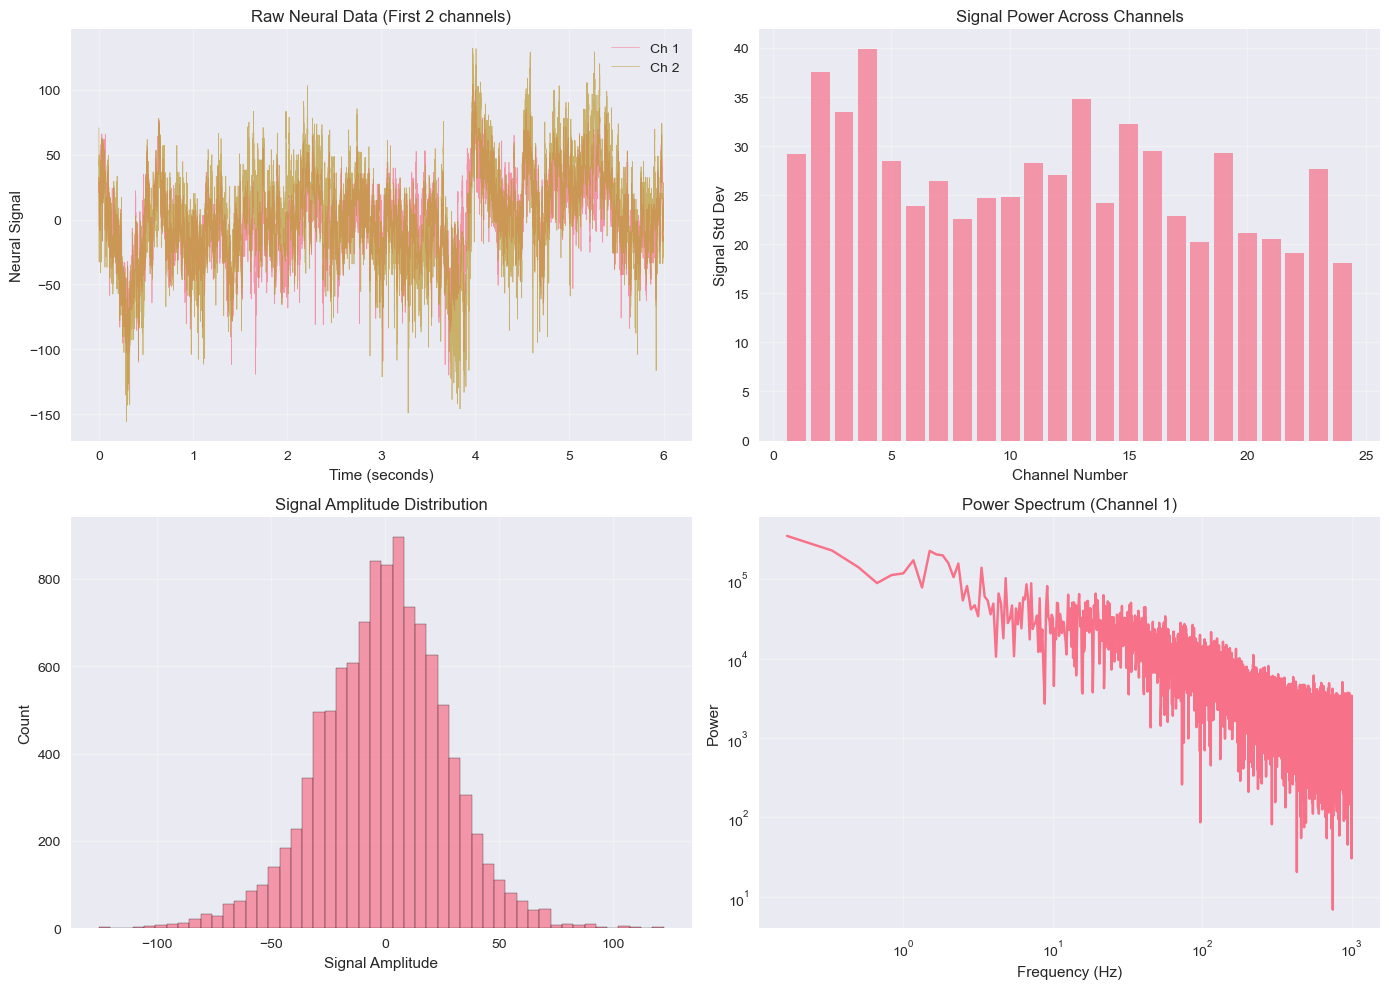


✅ Visualization complete!
Data quality: 26.91 mean signal power
Time range: 0.00 to 6.00 seconds


In [6]:
# Quick Visualization of Loaded Neural Data
if 'neural_data' in locals() and neural_data is not None:
    print("📊 Visualizing efficiently loaded neural data")
    
    # Create visualization
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Plot 1: Raw neural signals (first 8 channels, first 30 seconds)
    ax1 = axes[0, 0]
    time_axis = neural_data['times']
    n_channels_plot = min(2, neural_data['raw_data'].shape[1])
    time_limit = min(int(30 * neural_data['sampling_rate']), len(time_axis))
    
    for i in range(n_channels_plot):
        ax1.plot(time_axis[:time_limit], neural_data['raw_data'][:time_limit, i], 
                alpha=0.7, linewidth=0.5, label=f'Ch {i+1}')
    
    ax1.set_xlabel('Time (seconds)')
    ax1.set_ylabel('Neural Signal')
    ax1.set_title(f'Raw Neural Data (First {n_channels_plot} channels)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Signal power across channels
    ax2 = axes[0, 1]
    signal_power = np.std(neural_data['raw_data'], axis=0)
    channels = np.arange(1, len(signal_power) + 1)
    
    ax2.bar(channels, signal_power, alpha=0.7)
    ax2.set_xlabel('Channel Number')
    ax2.set_ylabel('Signal Std Dev')
    ax2.set_title('Signal Power Across Channels')
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Signal amplitude distribution
    ax3 = axes[1, 0]
    sample_data = neural_data['raw_data'][::100, :].flatten()  # Subsample for speed
    ax3.hist(sample_data, bins=50, alpha=0.7, edgecolor='black')
    ax3.set_xlabel('Signal Amplitude')
    ax3.set_ylabel('Count')
    ax3.set_title('Signal Amplitude Distribution')
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: Power spectrum (first channel)
    ax4 = axes[1, 1]
    if neural_data['raw_data'].shape[0] > 1000:
        # FFT of first 30 seconds from first channel
        signal_segment = neural_data['raw_data'][:time_limit, 0]
        freqs = np.fft.fftfreq(len(signal_segment), 1/neural_data['sampling_rate'])
        fft_data = np.abs(np.fft.fft(signal_segment))
        
        # Plot positive frequencies up to 1000 Hz
        positive_freqs = freqs[:len(freqs)//2]
        positive_fft = fft_data[:len(fft_data)//2]
        freq_mask = (positive_freqs > 0) & (positive_freqs <= 1000)
        
        ax4.loglog(positive_freqs[freq_mask], positive_fft[freq_mask])
        ax4.set_xlabel('Frequency (Hz)')
        ax4.set_ylabel('Power')
        ax4.set_title('Power Spectrum (Channel 1)')
        ax4.grid(True, alpha=0.3)
    else:
        ax4.text(0.5, 0.5, 'Not enough data\nfor spectral analysis', 
                ha='center', va='center', transform=ax4.transAxes)
    
    plt.tight_layout()
    plt.show()
    
    print("\n✅ Visualization complete!")
    print(f"Data quality: {np.mean(signal_power):.2f} mean signal power")
    print(f"Time range: {neural_data['times'][0]:.2f} to {neural_data['times'][-1]:.2f} seconds")
    
else:
    print("❌ No neural data available for visualization")
